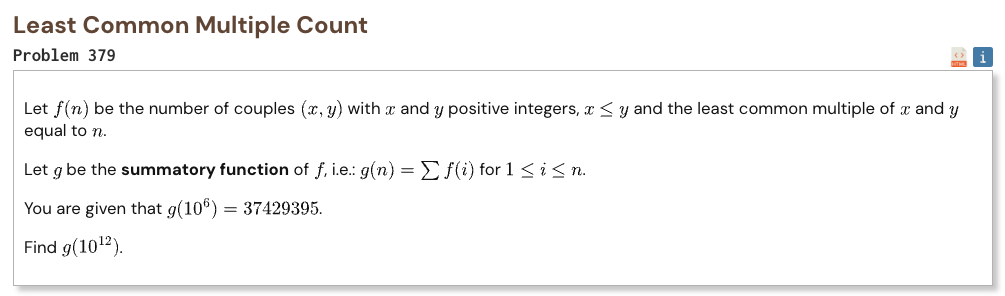

## Initial approach

* count ordered pairs first because they are easier to describe with prime exponents
* for each prime power p^e, there are 2e+1 exponent pairs whose maximum is e
* this ordered count can be rewritten with the squarefree indicator and the Möbius function
* the required unordered count is half of the ordered count plus the diagonal pairs
* reduce the problem to counting triples whose product is at most a given limit
* group equal floor division values so the large summations use only about square root many blocks
* use numba to compile the large integer loops and numpy to store the sieve arrays efficiently

In [1]:
import numpy as np
from numba import njit


@njit
def build_tables(limit):
    lowest_prime = np.zeros(limit + 1, dtype=np.int32)
    mobius = np.zeros(limit + 1, dtype=np.int8)
    primes = np.empty(limit // 10 + 100, dtype=np.int32)
    divisor_prefix = np.zeros(limit + 1, dtype=np.int64)

    mobius[1] = 1
    prime_count = 0

    for value in range(2, limit + 1):
        if lowest_prime[value] == 0:
            lowest_prime[value] = value
            mobius[value] = -1
            primes[prime_count] = value
            prime_count += 1

        for index in range(prime_count):
            prime = primes[index]
            product = value * prime

            if product > limit:
                break

            lowest_prime[product] = prime

            if value % prime == 0:
                mobius[product] = 0
                break

            mobius[product] = -mobius[value]

    for divisor in range(1, limit + 1):
        for multiple in range(divisor, limit + 1, divisor):
            divisor_prefix[multiple] += 1

    for value in range(1, limit + 1):
        divisor_prefix[value] += divisor_prefix[value - 1]

    return mobius, divisor_prefix


@njit
def count_pairs_with_product(limit, table_limit, divisor_prefix):
    if limit <= table_limit:
        return divisor_prefix[limit]

    total = np.int64(0)
    left = np.int64(1)

    while left <= limit:
        quotient = limit // left
        right = limit // quotient
        total += (right - left + 1) * quotient
        left = right + 1

    return total


@njit
def count_triples_with_product(limit, table_limit, divisor_prefix):
    total = np.int64(0)
    left = np.int64(1)

    while left <= limit:
        quotient = limit // left
        right = limit // quotient

        pair_count = count_pairs_with_product(
            quotient,
            table_limit,
            divisor_prefix,
        )

        total += (right - left + 1) * pair_count
        left = right + 1

    return total


@njit
def calculate_result(limit, table_limit, mobius, divisor_prefix):
    ordered_total = np.int64(0)
    root = np.int64(np.sqrt(limit))

    while (root + 1) * (root + 1) <= limit:
        root += 1

    while root * root > limit:
        root -= 1

    for value in range(1, root + 1):
        if mobius[value] != 0:
            reduced_limit = limit // (value * value)

            ordered_total += (
                np.int64(mobius[value])
                * count_triples_with_product(
                    reduced_limit,
                    table_limit,
                    divisor_prefix,
                )
            )

    return (ordered_total + limit) // 2


def solve(limit):
    table_limit = min(11_000_000, limit)
    mobius, divisor_prefix = build_tables(table_limit)

    return calculate_result(
        limit,
        table_limit,
        mobius,
        divisor_prefix,
    )


assert solve(10**6) == 37429395

In [2]:
%%time
result = solve(10**12)
print("Result:", result)

Result: 132314136838185
CPU times: user 9.87 s, sys: 84.1 ms, total: 9.96 s
Wall time: 9.96 s
